## Objective

This notebook audits the data quality of the `ohlcv` table for SOLUSDT 1-minute perpetual futures candles stored in the project DuckDB database. It checks time-range completeness, gap density, duplicate timestamps, candle geometry validity, return and volatility sanity, market microstructure activity, downstream table alignment, regime segmentation, and temporal price structure.

**Table:** `ohlcv` | **Asset:** SOLUSDT | **Granularity:** 1-minute candles

**Date:** 2026-06-16 | **Spec:** `_doc_/analysis/0024_ohlcv_table_spec.md`

The `ohlcv` table is treated as immutable market event data. Any data quality issue here can invalidate all downstream tables (`target`, `feat_ohlcv_quant`, `predictions`).

## Setup

In [1]:
import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from IPython.display import Markdown, display

DB_PATH = Path('../../database/solusdt/solusdt.duckdb')
con = duckdb.connect(str(DB_PATH), read_only=True)

CQ_COLORS = {
    'blue':       '#1696d2',
    'black':      '#000000',
    'gray_dark':  '#353535',
    'gray':       '#696969',
    'gray_light': '#d2d2d2',
    'yellow':     '#fdbf11',
    'orange':     '#f15a24',
    'red':        '#ec008b',
}
CQ_SEQUENCE = [
    CQ_COLORS['blue'], CQ_COLORS['yellow'], CQ_COLORS['orange'],
    CQ_COLORS['gray'], CQ_COLORS['red'],
]

sns.set_theme(
    style='whitegrid',
    rc={
        'figure.figsize':    (10, 5),
        'figure.dpi':        120,
        'axes.spines.top':   False,
        'axes.spines.right': False,
        'axes.edgecolor':    CQ_COLORS['gray'],
        'axes.labelcolor':   CQ_COLORS['gray_dark'],
        'xtick.color':       CQ_COLORS['gray_dark'],
        'ytick.color':       CQ_COLORS['gray_dark'],
        'grid.color':        CQ_COLORS['gray_light'],
        'grid.linewidth':    0.8,
        'axes.axisbelow':    True,
        'legend.frameon':    False,
    },
)
sns.set_palette(CQ_SEQUENCE)

SQRT_ANNUAL = np.sqrt(525_600)  # sqrt(minutes per year) for annualizing 1-min vol
VOL_WINDOW  = 43_200            # 30-day rolling window in minutes
import sys
sys.path.insert(0, "src")
from table_formatting import format_analysis_table, display_analysis_table

## 1. Time Coverage

**Purpose.** This table checks the completeness of the OHLCV time series: how many rows exist, how many should exist for a continuous 1-minute series, and how many minutes are missing.

**Method.** Computes MIN/MAX of `open_time`, row count, expected row count (minute span + 1), missing minutes, and duplicate `open_time` count from the `ohlcv` table.

**Interpretation.** Healthy: `missing_minutes = 0`, `duplicate_count = 0`. Any duplicates are critical — they invalidate the primary key. Large gaps suggest sync failures or exchange downtime.

**Action rule.** If `duplicate_count > 0` → critical flag, create todo for database_agent. If `missing_minutes > 1440` (>1 day) → investigate sync history.

In [2]:
#| label: tbl-time-coverage
#| tbl-cap: "OHLCV time coverage summary"

summary_df = con.execute("""
    SELECT
        MIN(open_time)::VARCHAR                                              AS first_open_time,
        MAX(open_time)::VARCHAR                                              AS last_open_time,
        COUNT(*)                                                             AS row_count,
        datediff('minute', MIN(open_time), MAX(open_time)) + 1              AS expected_row_count,
        datediff('minute', MIN(open_time), MAX(open_time)) + 1 - COUNT(*)   AS missing_minutes,
        COUNT(*) - COUNT(DISTINCT open_time)                                 AS duplicate_count
    FROM ohlcv
""").df()
display_analysis_table(summary_df)

first_open_time,last_open_time,row_count,expected_row_count,missing_minutes,duplicate_count
2020-09-14 07:00:00,2026-06-14 12:00:00,3022861,3022861,0,0


**Purpose.** This table lists the top 20 largest time gaps — consecutive missing minutes — in the OHLCV series.

**Method.** Uses a window `LEAD()` over `open_time` to compute the gap in minutes between each bar and the next; filters gaps > 1 minute; returns the 20 largest.

**Interpretation.** Healthy: no rows returned (no gaps > 1 min). Large gaps around weekends or exchange maintenance are expected for some assets; for SOLUSDT perpetuals, any gap > 60 min warrants inspection.

**Action rule.** Gaps > 1440 min (1 day) are critical. Annotate context (exchange outage, sync failure).

In [3]:
#| label: tbl-gap-top20
#| tbl-cap: "Top 20 largest time gaps in OHLCV (minutes)"

gaps_df = con.execute("""
    WITH ordered AS (
        SELECT
            open_time,
            LEAD(open_time) OVER (ORDER BY open_time) AS next_open_time
        FROM ohlcv
    )
    SELECT
        open_time::VARCHAR                                   AS gap_start,
        next_open_time::VARCHAR                              AS gap_end,
        datediff('minute', open_time, next_open_time)        AS gap_minutes
    FROM ordered
    WHERE next_open_time IS NOT NULL
      AND datediff('minute', open_time, next_open_time) > 1
    ORDER BY gap_minutes DESC
    LIMIT 20
""").df()
display_analysis_table(gaps_df)

gap_start,gap_end,gap_minutes


In [4]:
row_count  = int(summary_df['row_count'].iloc[0])
missing    = int(summary_df['missing_minutes'].iloc[0])
duplicates = int(summary_df['duplicate_count'].iloc[0])
max_gap    = int(gaps_df['gap_minutes'].max()) if len(gaps_df) > 0 else 0
gap_count  = len(gaps_df)

if duplicates > 0:
    dup_line = f'\u26a0\ufe0f CRITICAL: {duplicates:,} duplicate `open_time` values.'
else:
    dup_line = f'\u2705 No duplicate `open_time` values across {row_count:,} rows.'

if missing == 0:
    gap_line = '\u2705 No missing minutes \u2014 continuous 1-minute series.'
elif missing > 1440:
    gap_line = f'\u26a0\ufe0f CRITICAL: {missing:,} missing minutes across {gap_count} gaps (largest: {max_gap:,} min).'
else:
    gap_line = f'\u26a0\ufe0f {missing:,} missing minutes across {gap_count} gaps (largest: {max_gap:,} min).'

display(Markdown(f'**Finding:** {dup_line}  \n**Finding:** {gap_line}'))

**Finding:** ✅ No duplicate `open_time` values across 3,022,861 rows.  
**Finding:** ✅ No missing minutes — continuous 1-minute series.

## 2. Candle Validity

**Purpose.** This table counts per-row violations of candle geometry and price constraints across all OHLCV rows.

**Method.** SQL CASE expressions count rows violating each constraint: OHLC ordering (high ≥ open, high ≥ close, high ≥ low, low ≤ open, low ≤ close), positive prices (open/high/low/close > 0), non-negative activity (volume, quote_volume, trades, taker_buy_base, taker_buy_quote ≥ 0), and taker-buy consistency (taker_buy_base ≤ volume, taker_buy_quote ≤ quote_volume).

**Interpretation.** Healthy: all violation counts = 0. Any non-zero count in price/geometry checks is critical bad data.

**Action rule.** If any geometry or price violation > 0 → critical flag.

In [5]:
#| label: tbl-candle-validity
#| tbl-cap: "Candle geometry and price validity violation counts"

validity_df = con.execute("""
    SELECT
        SUM(CASE WHEN high < open                    THEN 1 ELSE 0 END) AS high_lt_open,
        SUM(CASE WHEN high < close                   THEN 1 ELSE 0 END) AS high_lt_close,
        SUM(CASE WHEN high < low                     THEN 1 ELSE 0 END) AS high_lt_low,
        SUM(CASE WHEN low  > open                    THEN 1 ELSE 0 END) AS low_gt_open,
        SUM(CASE WHEN low  > close                   THEN 1 ELSE 0 END) AS low_gt_close,
        SUM(CASE WHEN open  <= 0                     THEN 1 ELSE 0 END) AS open_lte_zero,
        SUM(CASE WHEN high  <= 0                     THEN 1 ELSE 0 END) AS high_lte_zero,
        SUM(CASE WHEN low   <= 0                     THEN 1 ELSE 0 END) AS low_lte_zero,
        SUM(CASE WHEN close <= 0                     THEN 1 ELSE 0 END) AS close_lte_zero,
        SUM(CASE WHEN volume        < 0              THEN 1 ELSE 0 END) AS volume_negative,
        SUM(CASE WHEN quote_volume  < 0              THEN 1 ELSE 0 END) AS quote_volume_negative,
        SUM(CASE WHEN trades        < 0              THEN 1 ELSE 0 END) AS trades_negative,
        SUM(CASE WHEN taker_buy_base  < 0            THEN 1 ELSE 0 END) AS taker_buy_base_negative,
        SUM(CASE WHEN taker_buy_quote < 0            THEN 1 ELSE 0 END) AS taker_buy_quote_negative,
        SUM(CASE WHEN taker_buy_base  > volume       THEN 1 ELSE 0 END) AS taker_buy_base_gt_volume,
        SUM(CASE WHEN taker_buy_quote > quote_volume THEN 1 ELSE 0 END) AS taker_buy_quote_gt_qvol
    FROM ohlcv
""").df()

validity_long = validity_df.T.reset_index()
validity_long.columns = ['check', 'violation_count']
validity_long['violation_count'] = validity_long['violation_count'].astype(int)
display_analysis_table(validity_long)

check,violation_count
high_lt_open,0
high_lt_close,0
high_lt_low,0
low_gt_open,0
low_gt_close,0
open_lte_zero,0
high_lte_zero,0
low_lte_zero,0
close_lte_zero,0
volume_negative,0


In [6]:
total_violations = int(validity_long['violation_count'].sum())
if total_violations == 0:
    display(Markdown('**Finding:** \u2705 All 16 candle geometry and price validity checks passed. Zero violations.'))
else:
    failing = validity_long[validity_long['violation_count'] > 0]
    details = ', '.join(
        f'{row["check"]} ({int(row["violation_count"]):,})'
        for _, row in failing.iterrows()
    )
    display(Markdown(f'**Finding:** \u26a0\ufe0f CRITICAL: {total_violations:,} violations detected: {details}'))

**Finding:** ✅ All 16 candle geometry and price validity checks passed. Zero violations.

## 3. Return and Volatility Sanity

**Purpose.** These tables inspect the distribution of 1-minute close-to-close log returns, identify extreme outliers, and check whether they are plausible market moves or bad data.

**Method.** Computes `log(close / lag(close, 1))` over the full series using a DuckDB window function. Distribution statistics (mean, std, percentiles) are computed from the full series. The top 20 most extreme absolute returns are surfaced for manual inspection.

**Interpretation.** Healthy: |log_ret| < 0.05 for > 99.9% of bars for SOL futures. Returns > 10% in a single 1-minute bar are suspicious and may indicate bad data or extreme market events.

**Action rule.** If extreme returns correlate with known exchange events (liquidations, circuit breakers), they are real. If isolated and not correlated, flag for database_agent.

In [7]:
# Compute log returns (shared by checks 3 and 7)
returns_df = con.execute("""
    SELECT
        open_time,
        close,
        volume,
        LN(close / NULLIF(LAG(close, 1) OVER (ORDER BY open_time), 0)) AS log_ret
    FROM ohlcv
    ORDER BY open_time
""").df()

returns_df['open_time'] = pd.to_datetime(returns_df['open_time'])
returns_df['year']      = returns_df['open_time'].dt.year
returns_df['month']     = returns_df['open_time'].dt.month
returns_df['date_only'] = returns_df['open_time'].dt.normalize()
returns_df['half_year'] = (
    returns_df['year'].astype(str) + '-'
    + np.where(returns_df['month'] <= 6, 'H1', 'H2')
)
print(f'Loaded {len(returns_df):,} rows, {returns_df["log_ret"].notna().sum():,} valid log returns')

Loaded 3,022,861 rows, 3,022,860 valid log returns


In [8]:
#| label: tbl-return-stats
#| tbl-cap: "1-minute log return distribution statistics"

lr = returns_df['log_ret'].dropna()
stats_df = pd.DataFrame({
    'statistic': ['count', 'mean', 'std', 'min', 'p1', 'p5', 'p25', 'median', 'p75', 'p95', 'p99', 'max'],
    'value': [
        f'{len(lr):,}',
        f'{lr.mean():.8f}',
        f'{lr.std():.8f}',
        f'{lr.min():.6f}',
        f'{lr.quantile(0.01):.6f}',
        f'{lr.quantile(0.05):.6f}',
        f'{lr.quantile(0.25):.6f}',
        f'{lr.median():.6f}',
        f'{lr.quantile(0.75):.6f}',
        f'{lr.quantile(0.95):.6f}',
        f'{lr.quantile(0.99):.6f}',
        f'{lr.max():.6f}',
    ]
})
display_analysis_table(stats_df)

statistic,value
count,"3,022,860"
mean,0.00000100
std,0.00174379
min,-0.125743
p1,-0.004677
p5,-0.002281
p25,-0.000647
median,0.000000
p75,0.000643
p95,0.002280


In [9]:
#| label: tbl-top-returns
#| tbl-cap: "Top 20 most extreme 1-minute log returns (absolute value)"

top_returns = (
    returns_df[['open_time', 'close', 'log_ret']]
    .dropna()
    .assign(abs_log_ret=lambda d: d['log_ret'].abs())
    .nlargest(20, 'abs_log_ret')
    .drop(columns='abs_log_ret')
    .assign(
        open_time=lambda d: d['open_time'].dt.strftime('%Y-%m-%d %H:%M'),
        log_ret=lambda d: d['log_ret'].map(lambda x: f'{x:.6f}'),
        close=lambda d: d['close'].map(lambda x: f'{x:.4f}'),
    )
    .reset_index(drop=True)
)
display_analysis_table(top_returns)

open_time,close,log_ret
2023-01-02 07:14,12.0650,0.185027
2021-05-19 12:57,32.8350,0.163048
2022-11-08 19:34,22.5300,0.151122
2025-10-10 21:18,155.1600,-0.125743
2022-11-09 18:47,11.4880,0.119602
2021-05-20 17:01,50.8670,0.117697
2022-11-10 03:17,14.6100,0.117372
2022-12-29 22:38,9.8500,0.114995
2021-05-19 14:00,36.9130,-0.108004
2021-05-19 12:58,29.5440,-0.105614


In [10]:
lr = returns_df['log_ret'].dropna()
max_abs      = float(lr.abs().max())
extreme_5pct = int((lr.abs() > 0.05).sum())
extreme_10pct = int((lr.abs() > 0.10).sum())

if extreme_10pct > 0:
    icon = '\u26a0\ufe0f CRITICAL'
    msg  = f'{extreme_10pct:,} bars with |log_ret| > 10% (max: {max_abs:.4f}). Inspect top returns table.'
elif extreme_5pct > 20:
    icon = '\u26a0\ufe0f'
    msg  = f'{extreme_5pct:,} bars with |log_ret| > 5%. Max absolute return: {max_abs:.4f}.'
else:
    icon = '\u2705'
    msg  = f'Return distribution within expected range. {extreme_5pct} bars > 5%, max: {max_abs:.4f}.'

display(Markdown(f'**Finding:** {icon} {msg}'))

**Finding:** ⚠️ CRITICAL 10 bars with |log_ret| > 10% (max: 0.1850). Inspect top returns table.

## 4. Market Microstructure / Activity Sanity

**Purpose.** These tables inspect the activity columns (`volume`, `quote_volume`, `trades`, `taker_buy_base`, `taker_buy_quote`) for nulls, zeros, structural breaks, and impossible ratios.

**Method.** SQL aggregates null counts, zero counts, mean/median/max per column, and the average taker buy ratio (`taker_buy_base / volume`). A yearly breakdown shows how activity evolves over time.

**Interpretation.** Healthy: zero nulls, very few zero-volume bars (exchange downtime only), taker buy ratio 0.3–0.7. Long runs of zero volume suggest stale/bad data.

**Action rule.** Null activity columns or zero-volume runs > 60 bars → flag for database_agent.

In [11]:
#| label: tbl-activity-stats
#| tbl-cap: "Market activity column null, zero, and distribution statistics"

activity_df = con.execute("""
    SELECT
        COUNT(*)                                                      AS total_rows,
        SUM(CASE WHEN volume         IS NULL THEN 1 ELSE 0 END)       AS volume_null,
        SUM(CASE WHEN volume         = 0     THEN 1 ELSE 0 END)       AS volume_zero,
        SUM(CASE WHEN quote_volume   IS NULL THEN 1 ELSE 0 END)       AS quote_volume_null,
        SUM(CASE WHEN trades         IS NULL THEN 1 ELSE 0 END)       AS trades_null,
        SUM(CASE WHEN taker_buy_base  IS NULL THEN 1 ELSE 0 END)      AS taker_buy_base_null,
        SUM(CASE WHEN taker_buy_quote IS NULL THEN 1 ELSE 0 END)      AS taker_buy_quote_null,
        ROUND(AVG(volume),            4)                               AS avg_volume,
        ROUND(MEDIAN(volume),         4)                               AS median_volume,
        ROUND(MAX(volume),            4)                               AS max_volume,
        ROUND(AVG(trades),            2)                               AS avg_trades,
        ROUND(MEDIAN(trades),         2)                               AS median_trades,
        ROUND(MAX(trades),            0)                               AS max_trades,
        ROUND(AVG(taker_buy_base / NULLIF(volume, 0)), 4)             AS avg_taker_buy_ratio
    FROM ohlcv
""").df()

activity_long = activity_df.T.reset_index()
activity_long.columns = ['metric', 'value']
display_analysis_table(activity_long)

metric,value
total_rows,3022861.000
volume_null,0.000
volume_zero,382.000
quote_volume_null,0.000
trades_null,0.000
taker_buy_base_null,0.000
taker_buy_quote_null,0.000
avg_volume,16172.907
median_volume,8312.000
max_volume,6569829.000


In [12]:
#| label: tbl-activity-yearly
#| tbl-cap: "Annual volume and trade statistics"

vol_yearly = con.execute("""
    SELECT
        CAST(YEAR(open_time) AS INTEGER)                               AS year,
        COUNT(*)                                                        AS bar_count,
        ROUND(SUM(volume), 2)                                           AS total_volume,
        ROUND(AVG(volume), 4)                                           AS avg_volume_per_bar,
        ROUND(SUM(trades), 0)                                           AS total_trades,
        ROUND(AVG(trades), 2)                                           AS avg_trades_per_bar,
        ROUND(AVG(taker_buy_base / NULLIF(volume, 0)), 4)              AS avg_taker_buy_ratio
    FROM ohlcv
    GROUP BY YEAR(open_time)
    ORDER BY year
""").df()
vol_yearly['year'] = vol_yearly['year'].astype('Int64').astype(str)
display_analysis_table(vol_yearly)

year,bar_count,total_volume,avg_volume_per_bar,total_trades,avg_trades_per_bar,avg_taker_buy_ratio
2020,156540,881316763.000,5629.978,8220485.000,52.510,47.82%
2021,525600,5131766547.000,9763.635,298771462.000,568.440,48.21%
2022,525600,9210653780.000,17524.075,350318818.000,666.510,49.66%
2023,525600,13390658751.000,25476.900,526016830.000,1000.790,49.78%
2024,527040,7328948799.000,13905.868,797346279.000,1512.880,49.64%
2025,525600,9006141551.300,17134.972,1065273427.000,2026.780,49.66%
2026,236881,3938963087.940,16628.447,327587896.000,1382.920,49.95%


In [13]:
null_count  = int(activity_df[['volume_null', 'quote_volume_null', 'trades_null',
                                'taker_buy_base_null', 'taker_buy_quote_null']].sum(axis=1).iloc[0])
zero_vol    = int(activity_df['volume_zero'].iloc[0])
taker_ratio = float(activity_df['avg_taker_buy_ratio'].iloc[0])

issues = []
if null_count > 0:
    issues.append(f'{null_count:,} null values in activity columns')
if zero_vol > 100:
    issues.append(f'{zero_vol:,} zero-volume bars (possible stale candles)')
if not (0.25 <= taker_ratio <= 0.75):
    issues.append(f'avg taker buy ratio {taker_ratio:.4f} outside expected 0.25\u20130.75 range')

if issues:
    display(Markdown('**Finding:** \u26a0\ufe0f Activity anomalies: ' + '; '.join(issues)))
else:
    display(Markdown(
        f'**Finding:** \u2705 No null activity fields. '
        f'{zero_vol:,} zero-volume bars. '
        f'Avg taker buy ratio {taker_ratio:.4f} (within normal range).'
    ))

**Finding:** ⚠️ Activity anomalies: 382 zero-volume bars (possible stale candles)

## 5. Downstream Alignment Readiness

**Purpose.** These tables compare the `open_time` coverage of `ohlcv` against the downstream tables `target`, `feat_ohlcv_quant`, and `predictions` to detect missing joins or orphan rows.

**Method.** For each downstream table that exists, reports MIN/MAX `open_time` and row count. A second query counts downstream rows whose `open_time` does not match any row in `ohlcv`.

**Interpretation.** Healthy: no orphan downstream rows; all downstream tables have `open_time` within ohlcv range. Downstream rows outside ohlcv range indicate a sync problem.

**Action rule.** Orphan downstream rows → critical; create todo for database_agent to investigate sync order.

In [14]:
#| label: tbl-coverage-comparison
#| tbl-cap: "Timestamp coverage comparison across all tables"

existing_tables = set(
    con.execute("""
        SELECT table_name FROM information_schema.tables WHERE table_schema = 'main'
    """).df()['table_name'].tolist()
)

coverage_rows = []
for tbl in ['ohlcv', 'target', 'feat_ohlcv_quant', 'predictions']:
    if tbl in existing_tables:
        row = con.execute(f"""
            SELECT
                '{tbl}'                  AS table_name,
                MIN(open_time)::VARCHAR  AS first_ts,
                MAX(open_time)::VARCHAR  AS last_ts,
                COUNT(*)                 AS row_count
            FROM {tbl}
        """).df()
    else:
        row = pd.DataFrame([{
            'table_name': tbl,
            'first_ts':   'TABLE NOT FOUND',
            'last_ts':    'TABLE NOT FOUND',
            'row_count':  0,
        }])
    coverage_rows.append(row)

coverage_df = pd.concat(coverage_rows, ignore_index=True)
coverage_df['row_count'] = coverage_df['row_count'].astype('Int64')
display_analysis_table(coverage_df)

table_name,first_ts,last_ts,row_count
ohlcv,2020-09-14 07:00:00,2026-06-14 12:00:00,3022861
target,2020-09-14 07:00:00,2026-06-14 12:00:00,3022861
feat_ohlcv_quant,2020-09-14 07:00:00,2026-06-14 12:00:00,3022861
predictions,2020-09-14 07:00:00,2026-06-14 12:00:00,3022861


In [15]:
#| label: tbl-missing-coverage
#| tbl-cap: "Downstream rows whose open_time is not present in ohlcv"

orphan_rows = []
for tbl in ['target', 'feat_ohlcv_quant', 'predictions']:
    if tbl in existing_tables:
        res = con.execute(f"""
            SELECT
                '{tbl}' AS table_name,
                COUNT(*) AS orphan_row_count
            FROM {tbl} t
            LEFT JOIN ohlcv o ON t.open_time = o.open_time
            WHERE o.open_time IS NULL
        """).df()
    else:
        res = pd.DataFrame([{'table_name': tbl, 'orphan_row_count': 0}])
    orphan_rows.append(res)

orphan_df = pd.concat(orphan_rows, ignore_index=True)
orphan_df['orphan_row_count'] = orphan_df['orphan_row_count'].astype('Int64')
display_analysis_table(orphan_df)

table_name,orphan_row_count
target,0
feat_ohlcv_quant,0
predictions,0


In [16]:
ohlcv_rows   = int(coverage_df.loc[coverage_df['table_name'] == 'ohlcv', 'row_count'].iloc[0])
total_orphans = int(orphan_df['orphan_row_count'].sum())
missing_tables = [r['table_name'] for _, r in coverage_df.iterrows() if r['first_ts'] == 'TABLE NOT FOUND']

issues = []
if missing_tables:
    issues.append(f'Tables not found: {", ".join(missing_tables)}')
if total_orphans > 0:
    for _, r in orphan_df[orphan_df['orphan_row_count'] > 0].iterrows():
        issues.append(f'{r["table_name"]}: {int(r["orphan_row_count"]):,} orphan rows')

if issues:
    display(Markdown('**Finding:** \u26a0\ufe0f Alignment issues: ' + '; '.join(issues)))
else:
    display(Markdown('**Finding:** \u2705 All downstream tables found and fully aligned with ohlcv. No orphan rows.'))

**Finding:** ✅ All downstream tables found and fully aligned with ohlcv. No orphan rows.

## 6. Regime Segmentation

**Purpose.** These tables summarize bar counts, price levels, volume, and trade activity by year and by month to detect distribution shifts and regime changes.

**Method.** SQL aggregates group by `YEAR(open_time)` and `(YEAR, MONTH)` respectively. Reports bar count, mean close, mean volume per bar, and mean trades per bar.

**Interpretation.** Healthy: stable bar counts per year (close to 525,600 for full years), gradual volume growth consistent with market development. Sudden volume drops or price-level jumps may indicate regime changes.

**Action rule.** Periods with bar count < 80% of expected (partial years excluded) warrant investigation.

In [17]:
#| label: tbl-regime-by-year
#| tbl-cap: "Regime summary by year"

regime_year = con.execute("""
    SELECT
        CAST(YEAR(open_time) AS INTEGER)     AS year,
        COUNT(*)                              AS bar_count,
        ROUND(AVG(close),     4)              AS mean_close,
        ROUND(MIN(close),     4)              AS min_close,
        ROUND(MAX(close),     4)              AS max_close,
        ROUND(AVG(volume),    4)              AS mean_volume,
        ROUND(AVG(trades),    2)              AS mean_trades
    FROM ohlcv
    GROUP BY YEAR(open_time)
    ORDER BY year
""").df()
regime_year['year'] = regime_year['year'].astype('Int64').astype(str)
display_analysis_table(regime_year)

year,bar_count,mean_close,min_close,max_close,mean_volume,mean_trades
2020,156540,2.084,1.075,3.527,5629.978,52.510
2021,525600,79.876,1.490,259.939,9763.635,568.440
2022,525600,58.181,7.893,179.400,17524.075,666.510
2023,525600,29.204,9.699,126.030,25476.900,1000.790
2024,527040,155.408,79.007,264.380,13905.868,1512.880
2025,525600,169.986,95.670,295.330,17134.972,2026.780
2026,236881,93.450,60.290,148.270,16628.447,1382.920


In [18]:
#| label: tbl-regime-by-month
#| tbl-cap: "Regime summary by year-month (last 24 months)"

regime_month = con.execute("""
    SELECT
        CAST(YEAR(open_time)  AS INTEGER) AS year,
        CAST(MONTH(open_time) AS INTEGER) AS month,
        COUNT(*)                           AS bar_count,
        ROUND(AVG(close),     4)           AS mean_close,
        ROUND(AVG(volume),    4)           AS mean_volume,
        ROUND(AVG(trades),    2)           AS mean_trades
    FROM ohlcv
    GROUP BY YEAR(open_time), MONTH(open_time)
    ORDER BY year DESC, month DESC
    LIMIT 24
""").df()
regime_month['year']  = regime_month['year'].astype('Int64').astype(str)
regime_month['month'] = regime_month['month'].astype('Int64').astype(str)
display_analysis_table(regime_month)

year,month,bar_count,mean_close,mean_volume,mean_trades
2026,6,19441,68.591,20139.999,1489.110
2026,5,44640,86.967,13157.597,960.310
2026,4,43200,84.017,14134.394,1056.410
2026,3,44640,87.318,17248.720,1425.630
2026,2,40320,86.308,22713.734,1958.260
2026,1,44640,132.468,14866.931,1512.900
2025,12,44640,129.269,14939.092,1775.910
2025,11,43200,148.735,18426.404,2623.670
2025,10,44640,202.279,19912.944,2847.760
2025,9,43200,219.237,17437.070,2236.450


In [19]:
n_years   = len(regime_year)
years_str = ', '.join(regime_year['year'].tolist())
vol_growth = (
    regime_year['mean_volume'].iloc[-1] / regime_year['mean_volume'].iloc[0]
    if len(regime_year) > 1 and regime_year['mean_volume'].iloc[0] > 0
    else 1.0
)
display(Markdown(
    f'**Finding:** \u2705 Dataset spans {n_years} year(s): {years_str}. '
    f'Average volume per bar grew {vol_growth:.1f}x from first to last year. '
    f'Inspect the yearly table for structural distribution shifts before selecting a training window.'
))

**Finding:** ✅ Dataset spans 7 year(s): 2020, 2021, 2022, 2023, 2024, 2025, 2026. Average volume per bar grew 3.0x from first to last year. Inspect the yearly table for structural distribution shifts before selecting a training window.

## 7. Temporal Price Structure and Volatility

This section detects whether the price series exhibits structural regime changes over time and quantifies how volatile each period is — informing the decision of which historical window to use for model development.

### 7a. Price Level Over Time

**Purpose.** This chart plots daily close prices with a 30-day rolling mean and ±1 standard deviation band to reveal long-term trend phases, regime shifts, and whether the series is stationary or trending.

**Method.** Daily closing prices are computed from `ohlcv` using `ARG_MAX(close, open_time)` per day. A 30-day rolling mean and std are applied in pandas.

**Interpretation.** Healthy: band width should vary across regimes (wider in high-vol periods). Sudden band discontinuities may indicate bad data.

**Action rule.** Discontinuities not explained by known market events → flag for database_agent.

In [20]:
daily_close = con.execute("""
    SELECT
        DATE_TRUNC('day', open_time)::DATE  AS dt,
        ARG_MAX(close, open_time)           AS close
    FROM ohlcv
    GROUP BY DATE_TRUNC('day', open_time)
    ORDER BY dt
""").df()
daily_close['dt']           = pd.to_datetime(daily_close['dt'])
daily_close['rolling_mean'] = daily_close['close'].rolling(30).mean()
daily_close['rolling_std']  = daily_close['close'].rolling(30).std()
daily_close['upper']        = daily_close['rolling_mean'] + daily_close['rolling_std']
daily_close['lower']        = daily_close['rolling_mean'] - daily_close['rolling_std']

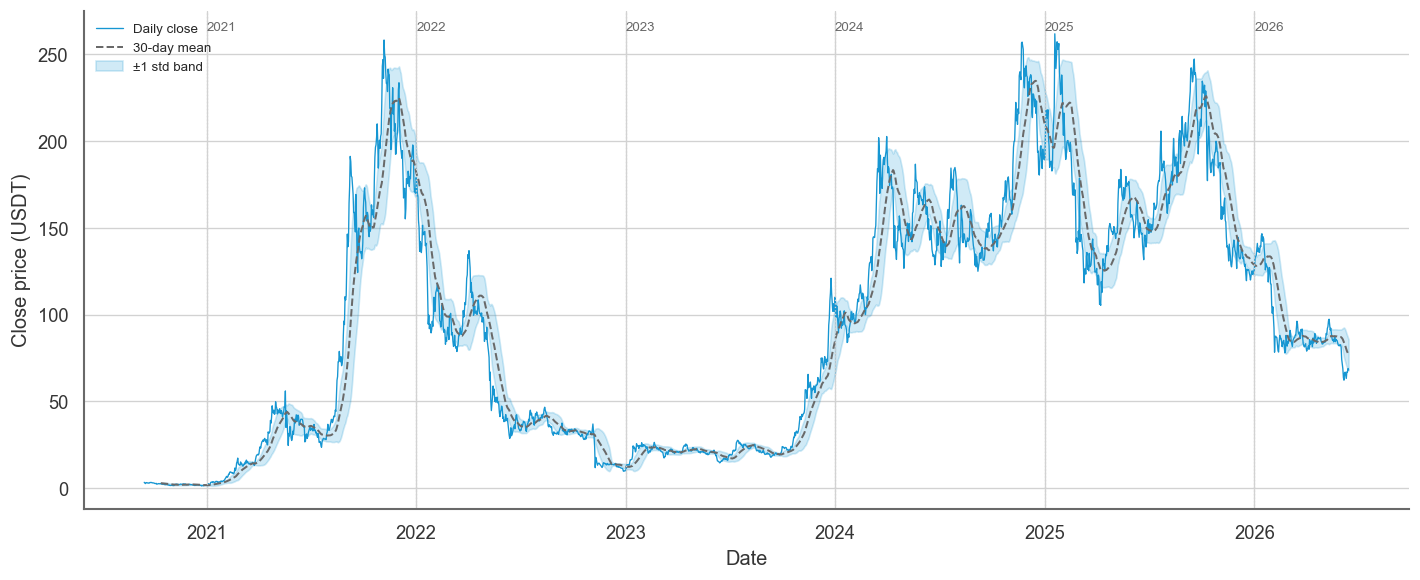

In [21]:
#| label: fig-close-price-time
#| fig-cap: "SOLUSDT daily close price with 30-day rolling mean and \u00b11 std band"
#| fig-alt: "Line chart of SOL daily close prices from first bar to last, with shaded 30-day rolling std band."

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(daily_close['dt'], daily_close['close'],
        color=CQ_COLORS['blue'], linewidth=0.8, label='Daily close')
ax.plot(daily_close['dt'], daily_close['rolling_mean'],
        color=CQ_COLORS['gray'], linewidth=1.2, linestyle='--', label='30-day mean')
ax.fill_between(
    daily_close['dt'],
    daily_close['lower'],
    daily_close['upper'],
    alpha=0.2,
    color=CQ_COLORS['blue'],
    label='\u00b11 std band',
)

# Year boundary vertical lines
years = daily_close['dt'].dt.year.unique()
for yr in sorted(years)[1:]:
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color=CQ_COLORS['gray_light'],
               linewidth=0.8, linestyle=':')
    ax.text(pd.Timestamp(f'{yr}-01-01'), ax.get_ylim()[1] * 0.98,
            str(yr), color=CQ_COLORS['gray'], fontsize=8, va='top', ha='left')

ax.set_xlabel('Date')
ax.set_ylabel('Close price (USDT)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [22]:
price_min = float(daily_close['close'].min())
price_max = float(daily_close['close'].max())
n_days    = len(daily_close)
display(Markdown(
    f'**Finding:** \u2705 Price series plotted over {n_days:,} trading days. '
    f'Close range: {price_min:.2f}\u2013{price_max:.2f} USDT. '
    f'Inspect chart for discontinuities and regime shifts.'
))

**Finding:** ✅ Price series plotted over 2,100 trading days. Close range: 1.20–261.90 USDT. Inspect chart for discontinuities and regime shifts.

### 7b. Period Volatility — Box Plots

**Purpose.** These box plots compare the distribution of daily realized volatility across years and half-years to identify structurally more volatile periods.

**Method.** Daily realized volatility is the standard deviation of 1-minute log returns within each calendar day, annualized by multiplying by `sqrt(525_600)`. Box plots then show the distribution of these daily vol values grouped by year and by half-year (H1 = Jan–Jun, H2 = Jul–Dec).

**Interpretation.** Healthy: gradual vol changes across periods. Sudden vol jumps (> 2× median) indicate regime change and should factor into the training window selection.

**Action rule.** If a period has median vol > 2× dataset-wide median, exclude from or weight-down in training window selection.

In [23]:
# Compute daily realized vol (annualized) from 1-min log returns
daily_vol = (
    returns_df.dropna(subset=['log_ret'])
    .groupby('date_only')['log_ret']
    .std()
    .reset_index()
    .rename(columns={'log_ret': 'daily_std'})
)
daily_vol['daily_rvol_ann'] = daily_vol['daily_std'] * SQRT_ANNUAL
daily_vol['date_only']      = pd.to_datetime(daily_vol['date_only'])
daily_vol['year']           = daily_vol['date_only'].dt.year
daily_vol['half_year']      = (
    daily_vol['year'].astype(str) + '-'
    + np.where(daily_vol['date_only'].dt.month <= 6, 'H1', 'H2')
)
print(f'Computed daily realized vol for {len(daily_vol):,} days')

Computed daily realized vol for 2,100 days


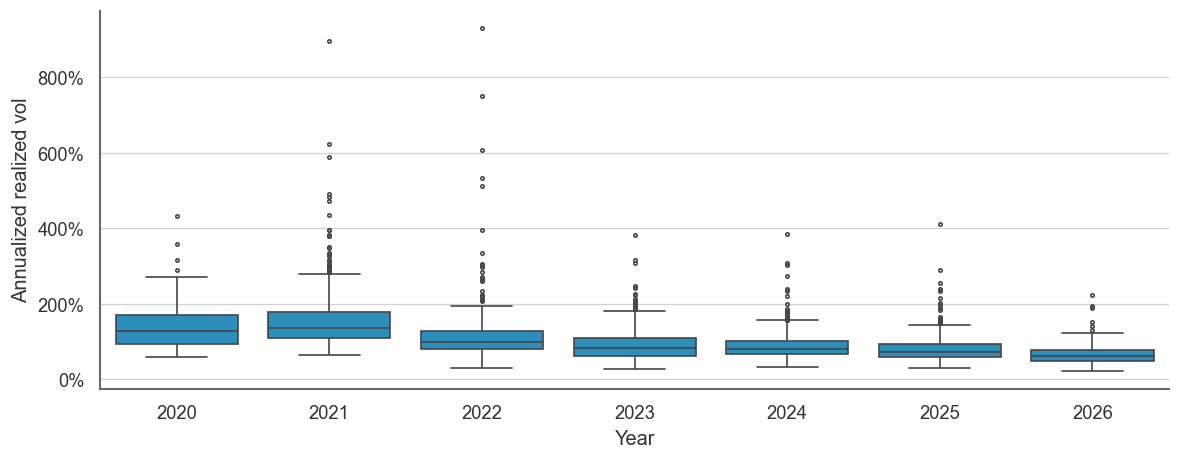

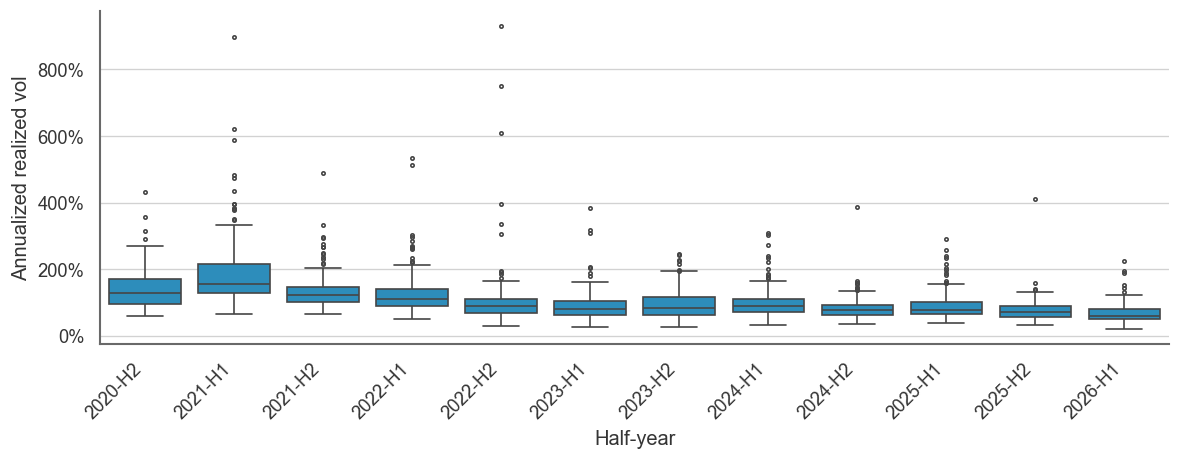

In [24]:
#| label: fig-vol-boxplots
#| fig-cap: "Annualized realized volatility distribution by period"
#| fig-subcap:
#|   - "By year"
#|   - "By half-year"
#| layout-ncol: 1

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(
    data=daily_vol,
    x='year', y='daily_rvol_ann',
    ax=ax,
    color=CQ_COLORS['blue'],
    flierprops=dict(marker='o', markersize=2, color=CQ_COLORS['gray']),
)
ax.set_xlabel('Year')
ax.set_ylabel('Annualized realized vol')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(
    data=daily_vol.sort_values('half_year'),
    x='half_year', y='daily_rvol_ann',
    ax=ax,
    color=CQ_COLORS['blue'],
    flierprops=dict(marker='o', markersize=2, color=CQ_COLORS['gray']),
)
ax.set_xlabel('Half-year')
ax.set_ylabel('Annualized realized vol')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
global_median_vol = float(daily_vol['daily_rvol_ann'].median())
yearly_medians    = daily_vol.groupby('year')['daily_rvol_ann'].median()
high_vol_years    = yearly_medians[yearly_medians > 2 * global_median_vol].index.tolist()

if high_vol_years:
    display(Markdown(
        f'**Finding:** \u26a0\ufe0f Year(s) {high_vol_years} have median realized vol > 2\u00d7 dataset median '
        f'({global_median_vol:.1%}). Consider excluding or down-weighting these periods in model training.'
    ))
else:
    display(Markdown(
        f'**Finding:** \u2705 No year exceeds 2\u00d7 the dataset-wide median realized vol '
        f'({global_median_vol:.1%}). Volatility regimes are comparable across years.'
    ))

**Finding:** ✅ No year exceeds 2× the dataset-wide median realized vol (90.2%). Volatility regimes are comparable across years.

### 7c. Rolling Volatility Line Chart

**Purpose.** This chart shows how annualized realized volatility evolves continuously over time using a 30-day rolling window, revealing gradual regime drift vs. sudden structural breaks.

**Method.** A 30-day rolling standard deviation of 1-minute log returns (window = 43,200 bars, min 1,000 bars) is multiplied by `sqrt(525_600)` to annualize. A shaded envelope (±1 std of the rolling vol itself, computed with a secondary 30-day rolling window) adds uncertainty context. Vertical lines mark year boundaries.

**Interpretation.** Healthy: smooth rolling vol without abrupt jumps (> 3× within a few days). Sudden spikes correlate with market events.

**Action rule.** Sustained vol elevation > 2× neighboring periods → consider training window cutoff at that boundary.

In [26]:
# Compute 30-day rolling vol on the 1-min return series
rv = returns_df.sort_values('open_time').copy()
rv['rolling_vol'] = rv['log_ret'].rolling(VOL_WINDOW, min_periods=1000).std() * SQRT_ANNUAL

# Daily-resample the rolling vol for plotting (reduces points for large datasets)
rv_daily = (
    rv.set_index('open_time')['rolling_vol']
    .resample('D')
    .last()
    .reset_index()
    .dropna()
)
rv_daily['rv_roll_mean'] = rv_daily['rolling_vol'].rolling(30).mean()
rv_daily['rv_roll_std']  = rv_daily['rolling_vol'].rolling(30).std()
rv_daily['rv_upper']     = rv_daily['rv_roll_mean'] + rv_daily['rv_roll_std']
rv_daily['rv_lower']     = (rv_daily['rv_roll_mean'] - rv_daily['rv_roll_std']).clip(lower=0)

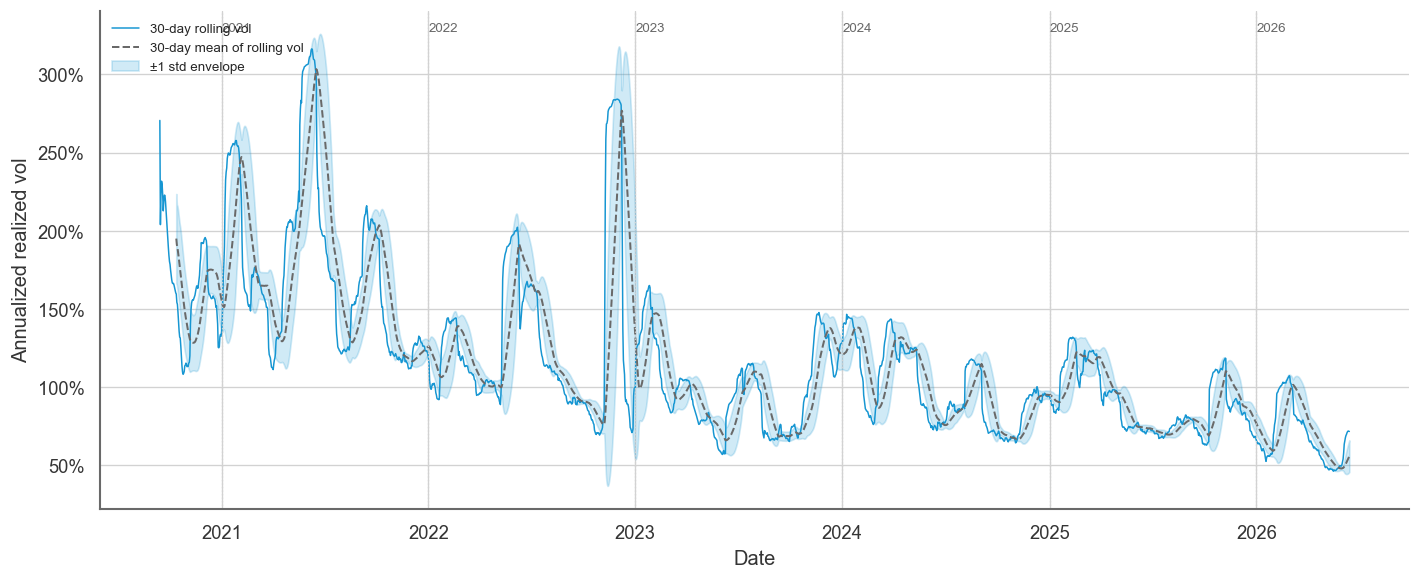

In [27]:
#| label: fig-rolling-vol
#| fig-cap: "30-day rolling annualized realized volatility with \u00b11 std envelope and year boundaries"
#| fig-alt: "Line chart of 30-day rolling annualized realized vol for SOLUSDT with shaded envelope."

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(rv_daily['open_time'], rv_daily['rolling_vol'],
        color=CQ_COLORS['blue'], linewidth=0.9, label='30-day rolling vol')
ax.plot(rv_daily['open_time'], rv_daily['rv_roll_mean'],
        color=CQ_COLORS['gray'], linewidth=1.2, linestyle='--', label='30-day mean of rolling vol')
ax.fill_between(
    rv_daily['open_time'],
    rv_daily['rv_lower'],
    rv_daily['rv_upper'],
    alpha=0.2,
    color=CQ_COLORS['blue'],
    label='\u00b11 std envelope',
)

# Year boundary lines
years_rv = rv_daily['open_time'].dt.year.unique()
for yr in sorted(years_rv)[1:]:
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color=CQ_COLORS['gray_light'],
               linewidth=0.8, linestyle=':')
    ax.text(pd.Timestamp(f'{yr}-01-01'), ax.get_ylim()[1] * 0.98,
            str(yr), color=CQ_COLORS['gray'], fontsize=8, va='top', ha='left')

ax.set_xlabel('Date')
ax.set_ylabel('Annualized realized vol')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [28]:
vol_max  = float(rv_daily['rolling_vol'].max())
vol_min  = float(rv_daily['rolling_vol'].min())
vol_mean = float(rv_daily['rolling_vol'].mean())
display(Markdown(
    f'**Finding:** \u2705 Rolling 30-day annualized vol ranges from {vol_min:.1%} to {vol_max:.1%} '
    f'(mean: {vol_mean:.1%}). '
    f'Inspect chart for sudden regime breaks. Sustained vol > 2\u00d7 mean warrants a training window cutoff.'
))

**Finding:** ✅ Rolling 30-day annualized vol ranges from 46.3% to 316.2% (mean: 116.9%). Inspect chart for sudden regime breaks. Sustained vol > 2× mean warrants a training window cutoff.

### 7d. Structural Break Indicators

**Purpose.** This table quantifies statistical properties of each year and half-year period to identify distribution shifts that would affect model training window selection.

**Method.** For each period: mean and std of `close`, mean and std of log return, 5th and 95th percentile of log return, maximum drawdown within period, and a Sharpe-proxy (mean / std of log return). Periods where any metric differs by more than 2× the dataset-wide value are flagged.

**Interpretation.** Periods with large deviations in vol, drawdown, or Sharpe-proxy indicate structural breaks. The most recent structurally stable window is the preferred training window.

**Action rule.** Use this table to select a training window start date aligned with a stable-regime boundary.

In [29]:
def _max_drawdown(prices: pd.Series) -> float:
    """Max drawdown (negative fraction) for a price series."""
    roll_max = prices.cummax()
    dd = prices / roll_max - 1.0
    return float(dd.min())

sb_rows = []
for period_col in ['year', 'half_year']:
    for period_val, grp in returns_df.groupby(period_col, sort=True):
        lr_grp  = grp['log_ret'].dropna()
        std_lr  = float(lr_grp.std()) if len(lr_grp) > 1 else float('nan')
        mean_lr = float(lr_grp.mean()) if len(lr_grp) > 0 else float('nan')
        sb_rows.append({
            'period_type':  period_col,
            'period':       str(period_val),
            'mean_close':   round(float(grp['close'].mean()), 4),
            'std_close':    round(float(grp['close'].std()),  4),
            'mean_log_ret': mean_lr,
            'std_log_ret':  std_lr,
            'p5_log_ret':   float(lr_grp.quantile(0.05)) if len(lr_grp) > 0 else float('nan'),
            'p95_log_ret':  float(lr_grp.quantile(0.95)) if len(lr_grp) > 0 else float('nan'),
            'max_drawdown': _max_drawdown(grp['close'].reset_index(drop=True)),
            'sharpe_proxy': mean_lr / std_lr if std_lr and std_lr > 0 else float('nan'),
        })

sb_df = pd.DataFrame(sb_rows)

In [30]:
#| label: tbl-structural-breaks
#| tbl-cap: "Structural break indicators per period (year and half-year). max_drawdown is negative."

# Dataset-wide reference values for flagging
global_std_lr  = float(returns_df['log_ret'].dropna().std())
global_mean_lr = float(returns_df['log_ret'].dropna().mean())

sb_display = sb_df.copy()
sb_display['mean_log_ret']  = sb_display['mean_log_ret'].map(lambda x: f'{x:.8f}')
sb_display['std_log_ret']   = sb_display['std_log_ret'].map(lambda x: f'{x:.8f}')
sb_display['p5_log_ret']    = sb_display['p5_log_ret'].map(lambda x: f'{x:.6f}')
sb_display['p95_log_ret']   = sb_display['p95_log_ret'].map(lambda x: f'{x:.6f}')
sb_display['max_drawdown']  = sb_display['max_drawdown'].map(lambda x: f'{x:.4f}')
sb_display['sharpe_proxy']  = sb_display['sharpe_proxy'].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'n/a')
display_analysis_table(sb_display)

period_type,period,mean_close,std_close,mean_log_ret,std_log_ret,p5_log_ret,p95_log_ret,max_drawdown,sharpe_proxy
year,2020,2.084,0.512,-0.00000497,0.00214827,-0.002994,0.002948,-0.6952,-0.0023
year,2021,79.876,76.897,0.00000899,0.00252988,-0.003485,0.003507,-0.6692,0.0036
year,2022,58.181,39.393,-0.00000540,0.00195695,-0.002434,0.002384,-0.9560,-0.0028
year,2023,29.204,19.307,0.00000442,0.00141682,-0.001915,0.001950,-0.5144,0.0031
year,2024,155.408,37.336,0.00000118,0.00136382,-0.001950,0.001951,-0.4763,0.0009
year,2025,169.986,35.343,-0.00000080,0.00124732,-0.001755,0.001730,-0.6761,-0.0006
year,2026,93.450,20.222,-0.00000255,0.00100545,-0.001408,0.001381,-0.5934,-0.0025
half_year,2020-H2,2.084,0.512,-0.00000497,0.00214827,-0.002994,0.002948,-0.6952,-0.0023
half_year,2021-H1,22.425,14.816,0.00001213,0.00299019,-0.004148,0.004122,-0.6692,0.0041
half_year,2021-H2,136.391,71.226,0.00000591,0.00197504,-0.002898,0.002955,-0.4587,0.0030


In [31]:
flagged = sb_df[
    sb_df['period_type'] == 'year'
].copy()
flagged['vol_ratio'] = flagged['std_log_ret'] / global_std_lr
high_vol_periods = flagged[flagged['vol_ratio'] > 2]['period'].tolist()
low_vol_periods  = flagged[flagged['vol_ratio'] < 0.5]['period'].tolist()

flagged_any = high_vol_periods + low_vol_periods
if flagged_any:
    display(Markdown(
        f'**Finding:** \u26a0\ufe0f Period(s) {flagged_any} have std(log_ret) deviating > 2\u00d7 from '
        f'dataset-wide std ({global_std_lr:.8f}). '
        f'Consider using a structurally stable sub-window for model training.'
    ))
else:
    display(Markdown(
        f'**Finding:** \u2705 No year shows std(log_ret) > 2\u00d7 or < 0.5\u00d7 the dataset-wide value '
        f'({global_std_lr:.8f}). All periods are structurally comparable.'
    ))

**Finding:** ✅ No year shows std(log_ret) > 2× or < 0.5× the dataset-wide value (0.00174379). All periods are structurally comparable.

## Summary

In [32]:
# Aggregate all findings into a summary
summary_lines = [
    f'**OHLCV Table Audit Summary — {pd.Timestamp.now().strftime("%Y-%m-%d")}**',
    '',
    f'**Coverage:** {int(summary_df["row_count"].iloc[0]):,} rows | '
    f'{summary_df["first_open_time"].iloc[0]} \u2013 {summary_df["last_open_time"].iloc[0]}',
    '',
    '**Check results:**',
    f'1. Time coverage: missing={int(summary_df["missing_minutes"].iloc[0]):,} min, '
    f'duplicates={int(summary_df["duplicate_count"].iloc[0]):,}, '
    f'gaps={len(gaps_df)}, max_gap={max_gap:,} min',
    f'2. Candle validity: {total_violations:,} violations across 16 checks',
    f'3. Return sanity: max |log_ret|={float(returns_df["log_ret"].dropna().abs().max()):.4f}, '
    f'bars >5%: {int((returns_df["log_ret"].dropna().abs() > 0.05).sum()):,}',
    f'4. Activity: volume_null={int(activity_df["volume_null"].iloc[0])}, '
    f'zero_vol_bars={int(activity_df["volume_zero"].iloc[0]):,}, '
    f'avg_taker_ratio={float(activity_df["avg_taker_buy_ratio"].iloc[0]):.4f}',
    f'5. Downstream alignment: {total_orphans:,} orphan rows, '
    f'missing tables: {missing_tables if missing_tables else "none"}',
    f'6. Regime: {n_years} year(s) covered, volume growth {vol_growth:.1f}x',
    f'7. Volatility: rolling vol {vol_min:.1%}\u2013{vol_max:.1%} '
    f'(mean {vol_mean:.1%}), flagged years: {flagged_any if flagged_any else "none"}',
]

# Determine overall status
critical_flags = (
    int(summary_df['duplicate_count'].iloc[0]) > 0
    or total_violations > 0
    or total_orphans > 0
)
status_icon = '\u274c CRITICAL ISSUES DETECTED' if critical_flags else '\u2705 All checks passed'
summary_lines.insert(2, f'**Overall status:** {status_icon}')

display(Markdown('  \n'.join(summary_lines)))

**OHLCV Table Audit Summary — 2026-06-16**  
  
**Overall status:** ✅ All checks passed  
**Coverage:** 3,022,861 rows | 2020-09-14 07:00:00 – 2026-06-14 12:00:00  
  
**Check results:**  
1. Time coverage: missing=0 min, duplicates=0, gaps=0, max_gap=0 min  
2. Candle validity: 0 violations across 16 checks  
3. Return sanity: max |log_ret|=0.1850, bars >5%: 86  
4. Activity: volume_null=0, zero_vol_bars=382, avg_taker_ratio=0.4935  
5. Downstream alignment: 0 orphan rows, missing tables: none  
6. Regime: 7 year(s) covered, volume growth 3.0x  
7. Volatility: rolling vol 46.3%–316.2% (mean 116.9%), flagged years: none